In [19]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from langchain_groq import ChatGroq
from dotenv import load_dotenv

In [20]:
load_dotenv()

True

In [21]:
class BlogState(TypedDict):
    topic : str
    outline : str
    content : str

llm = ChatGroq(
        model="llama-3.3-70b-versatile",   # Best model on Groq right now
        temperature=0.0,
        max_tokens=512,
    )    

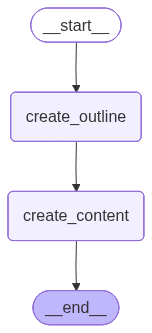

In [22]:

def create_outline(state: BlogState)-> BlogState:
    topic = state['topic']

    PROMPT = f'generate a detailed outline for blog with topic: {topic}'

    outline = llm.invoke(PROMPT).content

    state['outline'] = outline

    return state

def create_content(state: BlogState)-> BlogState:
    outline = state['topic']

    PROMPT = f'generate a detailed blog for blog with outline: {outline}'

    content = llm.invoke(PROMPT).content

    state['content'] = content
    
    return state

graph = StateGraph(BlogState)

graph.add_node('create_outline',create_outline)
graph.add_node('create_content',create_content)

graph.add_edge(START,'create_outline')
graph.add_edge('create_outline','create_content')
graph.add_edge('create_content', END)

workflow = graph.compile()
workflow

In [30]:
input_state = {'topic': 'how to make agentic system using langraph ?'}
output_state = workflow.invoke(input=input_state)

In [31]:
output_state['outline']

'Here is a detailed outline for a blog on "How to Make an Agentic System using LangChain":\n\n**Title:** "Building Intelligent Agentic Systems with LangChain: A Step-by-Step Guide"\n\n**Introduction**\n\n* Brief overview of agentic systems and their applications\n* Introduction to LangChain and its capabilities\n* Thesis statement: In this blog, we will explore how to build an agentic system using LangChain, a powerful tool for creating intelligent agents.\n\n**Section 1: What is an Agentic System?**\n\n* Definition of an agentic system and its key components (agents, environment, goals, etc.)\n* Examples of agentic systems in real-world applications (e.g. robotics, finance, healthcare)\n* Importance of agentic systems in modern technology\n\n**Section 2: Introduction to LangChain**\n\n* Overview of LangChain and its architecture\n* Key features of LangChain (e.g. natural language processing, reinforcement learning, etc.)\n* Advantages of using LangChain for building agentic systems\n\

In [32]:
output_state['content']

'**Title:** Creating an Agentic System using LangChain: A Step-by-Step Guide\n\n**Introduction:**\nIn recent years, the concept of agentic systems has gained significant attention in the field of artificial intelligence. An agentic system refers to a network of agents that interact with each other and their environment to achieve a common goal. LangChain, a popular framework for building conversational AI, provides an ideal platform for creating agentic systems. In this blog post, we will explore how to make an agentic system using LangChain, and provide a detailed guide on the process.\n\n**Outline:**\n\n1. **Introduction to Agentic Systems**\n2. **What is LangChain?**\n3. **Setting up LangChain**\n4. **Designing the Agentic System**\n5. **Implementing the Agentic System using LangChain**\n6. **Testing and Evaluating the Agentic System**\n7. **Conclusion**\n\n**1. Introduction to Agentic Systems:**\nAn agentic system is a network of agents that interact with each other and their envir